# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import make_regaxis, build_histogram

from tpvalidator.viz.display import TriggerPrimitivesEventViewer

from IPython.display import Markdown

# Data

In [16]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'gamma']
datasets = dctl.load('data/vd/1x8x14/old_detsim', dataset_names)
gm_ws=datasets['gamma']
em_ws=datasets['eminus']


['eminus', 'gamma']

Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace muminus skipped

...

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace mu-topo-z skipped

Workspace mu-topo-x skipped

Workspace marley skipped

Workspace radbkg skipped

# Analysis Code

In [4]:
from scipy.optimize import curve_fit
from matplotlib.axes import Axes
from typing import Literal
from tpvalidator.analysis.base import TrgWorkspaceAnalyzer
from tpvalidator.detgeometry import FDVDGeometry_1x8x14
from tpvalidator.viz.textual import format_val_err

#---------
def line(x, m, b):
    return m * x + b

# TODO: Generalize?
def plot_fit(
    x: np.ndarray,
    y: np.ndarray,
    m: float,
    b: float,
    ax: Axes,
    m_err: float = 0,
    b_err: float = 0,
    c: np.ndarray = None,
    label_x: str = '',
    label_y: str = '',
) -> None:
    """Plot data points with a linear fit and uncertainty band.

    Args:
        x: Independent variable values.
        y: Dependent variable values.
        m: Slope of the fitted line.
        b: Intercept of the fitted line.
        ax: Matplotlib axes to draw on.
        m_err: Uncertainty on the slope (used for the shaded band).
        b_err: Uncertainty on the intercept (used for the shaded band).
        label_x: Label for the x-axis.
        label_y: Label for the y-axis.
    """

    sc = ax.scatter(x, y, s=5, c=c, alpha=1)
    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)

    xmin, xmax = ax.get_xlim()
    xmin, xmax = x.min(), x.max()


    lx, ly = [], []

    lx.append(xmin)
    ly.append(line(lx[0], m, b))

    lx.append(xmax)
    ly.append(line(lx[1], m, b))


    ley_down = []
    ley_down.append(line(lx[0], m-m_err, b-b_err))
    ley_down.append(line(lx[1], m-m_err, b-b_err))

    ley_up = []
    ley_up.append(line(lx[0], m+m_err, b+b_err))
    ley_up.append(line(lx[1], m+m_err, b+b_err))


    ax.plot(lx, ly, color='r')   
    plt.fill_between(lx, ley_down, ley_up, alpha=0.3)
    ax.figure.colorbar(sc, label='Drift depth [x]', ax=ax)


# TODO: move to histograms?
def profile_with_spread(
    h: hist.Hist,
    profile_axis: str,
    error: Literal["sem", "std"] = "sem",
) -> hist.Hist:
    """Compute a profile histogram with spread (mean ± error) along one axis.

    Collapses `profile_axis` by computing the bin-weighted mean and spread of
    the remaining axes. The result uses ``hist.storage.Weight`` so that
    ``.value`` and ``.variance`` fields hold the mean and squared error.

    Args:
        h: Input histogram with at least one named axis.
        profile_axis: Name of the axis to profile over.
        error: Spread metric to store — ``"sem"`` (standard error of the mean)
            or ``"std"`` (standard deviation).

    Returns:
        Histogram over the non-profiled axes with mean as value and
        ``error**2`` as variance.
    """
    axes_names = [ax.name for ax in h.axes]
    assert profile_axis in axes_names, f"Axis '{profile_axis}' not found"
    assert error in ("sem", "std"), "error must be 'sem' or 'std'"

    profile_idx = axes_names.index(profile_axis)
    centers_profile = h.axes[profile_axis].centers

    counts = h.values()

    # Move profile axis to last position for broadcasting
    counts = np.moveaxis(counts, profile_idx, -1)

    N = counts.sum(axis=-1)
    mean = (counts * centers_profile).sum(axis=-1) / N
    mean2 = (counts * centers_profile**2).sum(axis=-1) / N
    std = np.sqrt(mean2 - mean**2)
    sem = std / np.sqrt(N)

    chosen_error = sem if error == "sem" else std

    # Replace empty bins with nan
    empty = N == 0
    mean = np.where(empty, np.nan, mean)
    chosen_error = np.where(empty, np.nan, chosen_error)

    # Build output with Weight storage so .value and .variance are available
    other_axes = [ax for ax in h.axes if ax.name != profile_axis]
    out = hist.Hist(*other_axes, storage=hist.storage.Weight())
    out.view(flow=False)[...] = np.stack([mean, chosen_error**2], axis=-1)

    return out

class CalibrationAnalyzer(TrgWorkspaceAnalyzer):
    """Energy calibration tool that maps per-ROP SADC sums to true kinetic energy.

    Wraps a single-particle workspace and fits a linear relationship between
    the summed ADC integral in each readout plane and the MC truth kinetic
    energy.  Both the forward (SADC → E) and inverse (E → SADC) calibrations
    are supported.
    """

    default_figsize=(8,6)

    #---------
    def __init__(self, sp_ws:pd.DataFrame, tps_cut:str=None):
        """
        Args:
            sp_ws: Single-particle analysis workspace exposing ``.tps`` and
                ``.mctruths`` DataFrames.
            tps_cut: Optional pandas query string applied to ``.tps`` before
                computing SADC sums (e.g. ``"peak_adc > 50"``).
        """

        super(CalibrationAnalyzer, self).__init__(sp_ws)
        # self._ws = sp_ws
        self._tps_cut = tps_cut
        self._calib_df = None

    
    #---------
    def calib_df(self):
        """Build per-event calibration DataFrame.

        Returns:
            DataFrame indexed by ``event_uid`` with columns ``kinetic_energy``
            (MeV) and ``sadc_rop_{i}`` (summed ADC integral) for each readout
            plane.  Events missing from either source are filled with 0.
        """

        if self._calib_df is None:
            ws = self._ws
            tps = ws.tps if self._tps_cut is None else ws.tps.query(self._tps_cut)

            adc_int_sum = pd.DataFrame({f'sadc_rop_{rop}':df_rop.groupby(['event_uid']).adc_integral.sum() for rop, df_rop in tps.groupby('readout_plane_id')}).fillna(0)
            # ekin = ws.mctruths[['event_uid', 'kinetic_energy']]
            ekin = ws.mctruths.copy()

            # Switch to MeV
            ekin['kinetic_energy'] = ekin['kinetic_energy']*1000
            self._calib_df = ekin.join(adc_int_sum, on='event_uid', how='outer').fillna(0)

        return self._calib_df
    
    #---------
    def compute_calibration(self, query:str=None) -> tuple:
        """Fit SADC vs kinetic energy linearly for each readout plane.

        Returns:
            DataFrame with one row per readout plane and columns
            ``m``, ``b``, ``m_err``, ``b_err`` (slope, intercept, and their
            1-sigma uncertainties from the covariance matrix).
        """
        calib_df = self.calib_df()

        if query:
            calib_df = calib_df.query(query)

        rows = []
        for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
            fit_df = calib_df[calib_df[f'sadc_rop_{rop}'] > 0 ]

            popt, pcov = curve_fit(
                line, fit_df['kinetic_energy'].values, fit_df[f'sadc_rop_{rop}'].values,
            )

            m, b = popt
            m_err, c_err = np.sqrt(np.diag(pcov))

            rows.append({
                'm': m, 'b':b, 'm_err':m_err, 'b_err':c_err
            })
        return pd.DataFrame(rows)

    
    #---------
    def plot_calibration(self, rop:int, query:str=None, **fig_kwargs):
        """Plot SADC vs kinetic energy with a linear fit for one readout plane.

        Args:
            rop: Readout plane index.
            figsize: Figure size passed to ``plt.subplots``.
            **fig_kwargs: Additional keyword arguments forwarded to ``plt.subplots``.

        Returns:
            The matplotlib Figure.
        """
        cal_df = self.calib_df()
        if query:
            cal_df = cal_df.query(query)
        cal_fit = self.compute_calibration(query=query)

        if 'figsize' not in fig_kwargs:
            fig_kwargs['figsize'] = self.default_figsize
        fig, ax = plt.subplots(1,1, **fig_kwargs)
        plot_fit(cal_df.kinetic_energy, cal_df[f'sadc_rop_{rop}'], c=cal_df.x, label_x='$E_{kin}$ [MeV]', label_y='SADC', ax=ax, **(cal_fit.iloc[rop]))
        ax.set_title(f'adc_integral - Energy calibration (plane {rop})')

        slope, intercept, slope_err, intercept_err = cal_fit.iloc[rop]

        # Stat box
        stats_text = "\n".join([
            r"$\bf{Linear\ Fit}$",
            f"m = {format_val_err(slope, slope_err)} adc/MeV",
            f"b = {format_val_err(intercept, intercept_err)} adc",
            # f"R²        = {r2:.4f}",
            # f"Std res   = {residuals.std():.3f}",
            # f"N         = {n}",
        ])

        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8),
                # fontfamily="monospace"
                )

        fig.tight_layout()
        return fig
    
    #---------
    def plot_calibration_spread(self, rop:int, ke_binsize:int=5, sadc_binsize:int=2000, cmap:str='viridis', figsize=default_figsize):
        """Plot 2D SADC vs energy histogram with a profile and relative-spread panel.

        The top panel shows a 2D histogram with the mean SADC profile overlaid.
        The bottom panel shows the relative spread σ_SADC / SADC as a function
        of kinetic energy.

        Args:
            rop: Readout plane index.
            ke_binsize: Bin width for the kinetic-energy axis (MeV).
            sadc_binsize: Bin width for the SADC axis (ADC counts).
            cmap: Colormap name for the 2D histogram.
            figsize: Figure size.
        """
        cal_df = self.calib_df()
    
        ke_axis = make_regaxis(cal_df, 'kinetic_energy', ke_binsize, label='$E_{kin}$ [MeV]')
        sadc_axis = make_regaxis(cal_df, f'sadc_rop_{rop}', sadc_binsize, label='SADC')

        h = build_histogram(cal_df, [ke_axis, sadc_axis])

        import copy

        h_plot = copy.deepcopy(h)
        vals = h_plot.view()
        h_plot.view()[vals == 0] = np.nan  # mplhep treats NaN as masked


        fig, axes = plt.subplot_mosaic(
            [["top", "cbar"],
            ["bot", "."  ]],
            figsize=figsize,
            gridspec_kw={"width_ratios": [20, 1], "height_ratios": [4, 1],
                        "hspace": 0.05, "wspace": 0.1},
        )
        ax_top = axes["top"]
        ax_bot = axes["bot"]
        cax    = axes["cbar"]

        hep.hist2dplot(h_plot, ax=ax_top, cbar=False, cmap=cmap)

        mesh = ax_top.collections[0]             # grab the QuadMesh for the colorbar
        plt.colorbar(mesh, cax=cax, label="Counts")

        h_prof = profile_with_spread(h, f'sadc_rop_{rop}', error='std')

        hep.histplot(h_prof, histtype='errorbar', ax=ax_top, color="crimson")
        ax_top.grid()
        # Hide ticks AND labels
        ax_top.tick_params(bottom=False, labelbottom=False)
        x_label = ax_top.get_xlabel()

        ax_top.set_xlabel(None)


        ax_bot.axhline(1, color="gray", linestyle="--", linewidth=0.8)

        ax_bot.plot(h_prof.axes['kinetic_energy'].centers, np.sqrt(h_prof.variances())/h_prof.values(), color="crimson")
        ax_bot.grid()
        ax_bot.set_xlabel(x_label)
        ax_bot.set_ylabel(r'$\sigma_{SADC}/SACD$')


        ax_top.set_title(f"SADC spread as a function of energy (plane {rop})")
        # fig.tight_layout()

    #---------
    def compute_calibration_inv(self, query:str=None) -> tuple:
        """Fit kinetic energy vs SADC linearly for each readout plane (inverse calibration).

        Returns:
            DataFrame with one row per readout plane and columns
            ``m``, ``b``, ``m_err``, ``b_err`` (slope, intercept, and their
            1-sigma uncertainties from the covariance matrix).
        """
        calib_df = self.calib_df()
        if query:
            calib_df = calib_df.query(query)
            
        rows = []
        for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
            fit_df = calib_df[calib_df[f'sadc_rop_{rop}'] > 0 ]

            popt, pcov = curve_fit(
                line, fit_df[f'sadc_rop_{rop}'].values, fit_df['kinetic_energy'].values
            )

            m, b = popt
            m_err, c_err = np.sqrt(np.diag(pcov))

            rows.append({
                'm': m, 'b':b, 'm_err':m_err, 'b_err':c_err
            })
        return pd.DataFrame(rows)

    #---------
    def plot_calibration_inv(self, rop:int, query:str=None, **fig_kwargs):
        """Plot kinetic energy vs SADC (inverse calibration) with a linear fit.

        Args:
            rop: Readout plane index.
            figsize: Figure size passed to ``plt.subplots``.
            **kwargs: Additional keyword arguments forwarded to ``plt.subplots``.

        Returns:
            The matplotlib Figure.
        """
        cal_df = self.calib_df()
        if query:
            cal_df = cal_df.query(query)
        cal_inv_fit = self.compute_calibration_inv()

        if 'figsize' not in fig_kwargs:
            fig_kwargs['figsize'] = self.default_figsize

        fig, ax = plt.subplots(1,1, **fig_kwargs)
        plot_fit(cal_df[f'sadc_rop_{rop}'], cal_df.kinetic_energy, c=cal_df.x, label_y='$E_{kin}$ [MeV]', label_x='SADC', ax=ax, **(cal_inv_fit.iloc[rop]))
        ax.set_title(f'adc_integral - Energy calibration (plane {rop})')

        slope, intercept, slope_err, intercept_err = cal_inv_fit.iloc[rop]

        # Stat box
        stats_text = "\n".join([
            r"$\bf{Linear\ Fit}$",
            f"m = {format_val_err(slope, slope_err)} adc/MeV",
            f"b = {format_val_err(intercept, intercept_err)} adc",
            # f"R²        = {r2:.4f}",
            # f"Std res   = {residuals.std():.3f}",
            # f"N         = {n}",
        ])

        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8),
                # fontfamily="monospace"
                )

        fig.tight_layout()
        return fig

# Energy Calibration

This noteboosk calculates the TP energy calibration for Simple Threshold TPs, using the `adc_integral` sum over particle gun events: single electrons or single gammas

## E-minus sample

In [5]:
em_ca = CalibrationAnalyzer(em_ws)

For each event in the e- dataset, the sum of `adc_integral` is calculated per plane, and associated to the event energy.

The calibration is calculated as a linear fit to `sum_adc` and `kinetic_energy`

In [ ]:
em_calib_df = em_ca.calib_df()
display(em_calib_df)

em_cal = em_ca.compute_calibration()
display(em_cal)

em_cal_inv = em_ca.compute_calibration_inv()
display(em_cal_inv)


,,event,run,subrun,pdg,process,status_code,block_id,truth_track_id,generator_name,x,...,px,py,pz,p,energy,kinetic_energy,event_uid,sadc_rop_0,sadc_rop_1,sadc_rop_2
entry,subentry,,,,,,,,,,,,,,,,,,,,,
0,0,1,20000011,0,11,primary,1,0,-1,generator,17.655194,...,-0.008742,-0.003572,-0.020669,0.022724,0.022730,22.218892,20000011000001,17519.0,19484.0,54957.0
1,0,2,20000011,0,11,primary,1,0,-1,generator,-215.683705,...,-0.000039,-0.006164,-0.009651,0.011451,0.011463,10.951618,20000011000002,52.0,0.0,0.0
2,0,3,20000011,0,11,primary,1,0,-1,generator,-80.812049,...,0.031295,-0.000804,0.025085,0.040116,0.040119,39.608298,20000011000003,24294.0,27772.0,90792.0
3,0,4,20000011,0,11,primary,1,0,-1,generator,-224.481508,...,-0.005738,0.007195,0.017102,0.019420,0.019427,18.916121,20000011000004,16342.0,16799.0,30675.0
4,0,5,20000011,0,11,primary,1,0,-1,generator,103.476405,...,0.024697,0.037609,-0.019185,0.048912,0.048915,48.403791,20000011000005,62177.0,71131.0,129034.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,996,20000011,0,11,primary,1,0,-1,generator,104.311123,...,-0.001343,0.000018,0.001478,0.001997,0.002062,1.550719,20000011000996,0.0,0.0,0.0
996,0,997,20000011,0,11,primary,1,0,-1,generator,-288.775510,...,0.001085,-0.001463,0.001999,0.002704,0.002752,2.241050,20000011000997,1837.0,2205.0,3505.0
997,0,998,20000011,0,11,primary,1,0,-1,generator,264.786452,...,-0.005954,-0.015037,-0.005675,0.017140,0.017148,16.636964,20000011000998,22288.0,14449.0,47616.0


,m,b,m_err,b_err
0,951.697762,-1846.149082,18.691227,1074.492604
1,979.588565,-1740.765196,21.057586,1212.594368
2,2432.897134,-5567.223798,27.702895,1611.296143


,m,b,m_err,b_err
0,0.000765,15.018973,0.000015,0.835450
1,0.000706,16.721912,0.000015,0.878771
2,0.000366,7.620584,0.000004,0.578134


# Results - e-minus

In [7]:
from IPython.display import Markdown, display
display(Markdown(em_cal.to_markdown(headers=["Slope", "Intercept", "Slope error", "Intercept error"])))


|    |    Slope |   Intercept |   Slope error |   Intercept error |
|---:|---------:|------------:|--------------:|------------------:|
|  0 |  951.698 |    -1846.15 |       18.6912 |           1074.49 |
|  1 |  979.589 |    -1740.77 |       21.0576 |           1212.59 |
|  2 | 2432.9   |    -5567.22 |       27.7029 |           1611.3  |

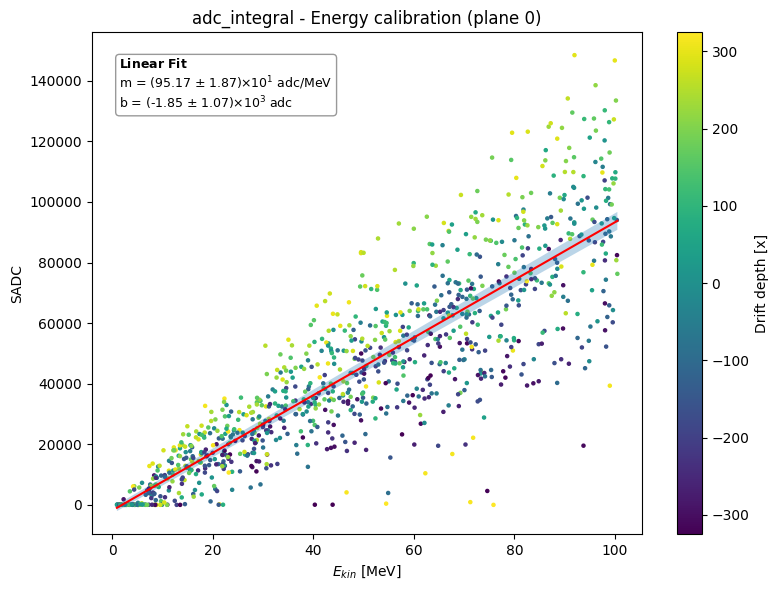

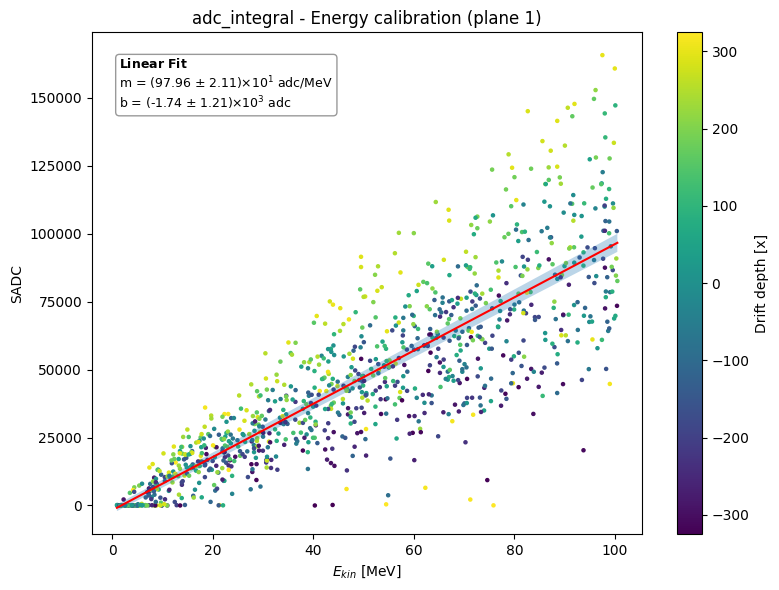

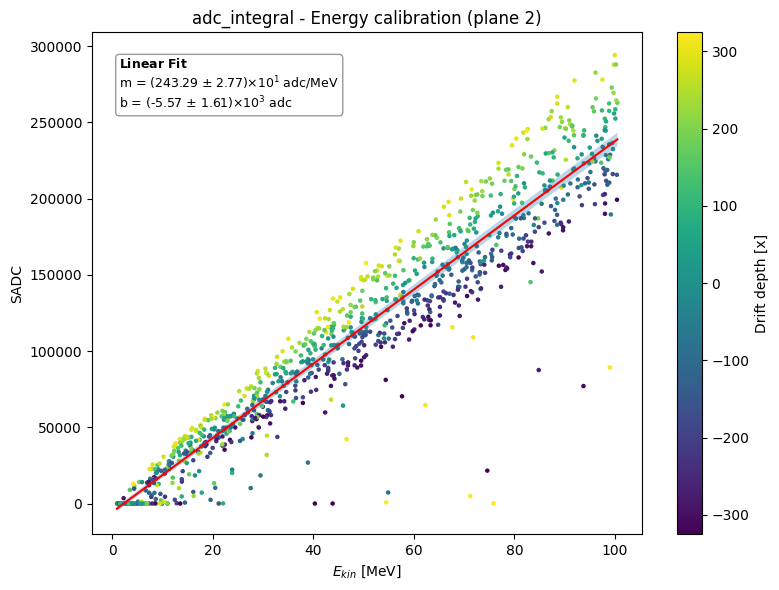

In [8]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    fig = em_ca.plot_calibration(rop)

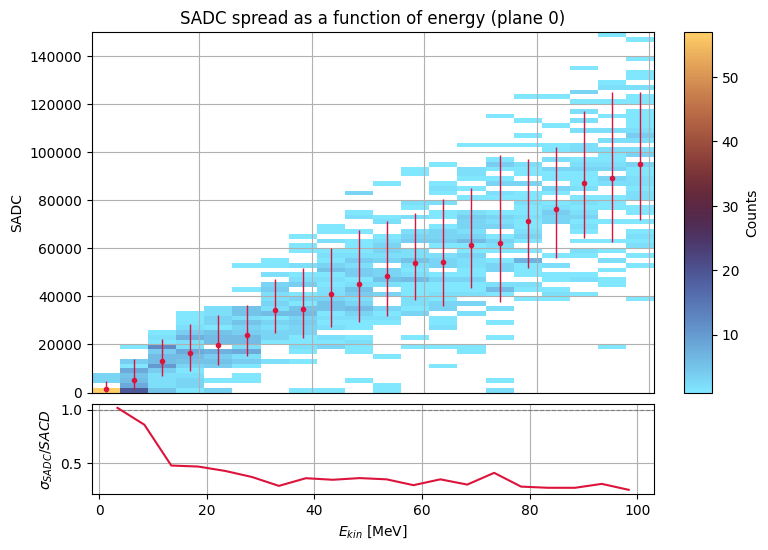

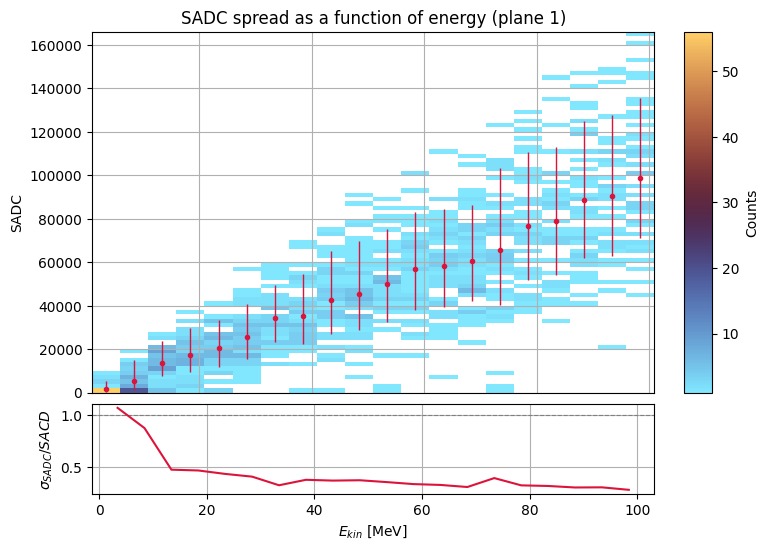

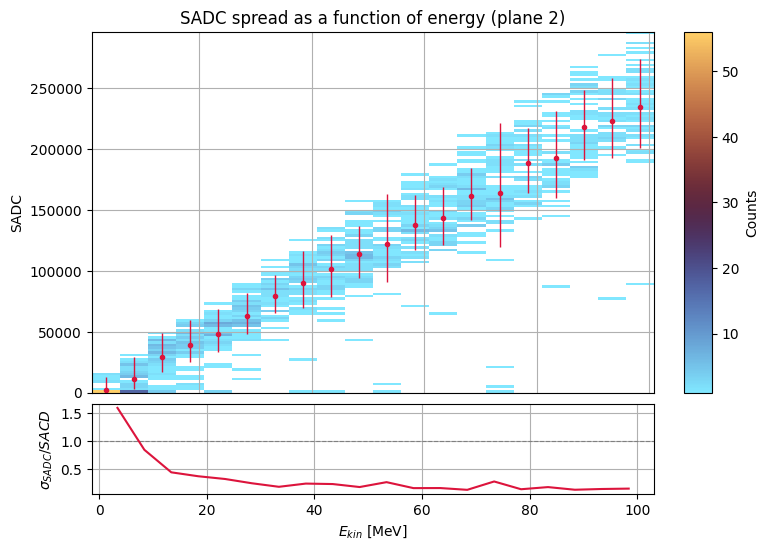

In [9]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    em_ca.plot_calibration_spread(rop, cmap='managua_r')

## Gammas

In [10]:
gm_ca = CalibrationAnalyzer(gm_ws)

In [11]:
gm_calib_df = gm_ca.calib_df()
display(gm_calib_df)

gm_cal = gm_ca.compute_calibration()
display(gm_cal)

,,event,run,subrun,pdg,process,status_code,block_id,truth_track_id,generator_name,x,...,px,py,pz,p,energy,kinetic_energy,event_uid,sadc_rop_0,sadc_rop_1,sadc_rop_2
entry,subentry,,,,,,,,,,,,,,,,,,,,,
0,0,1,20000011,0,22,primary,1,0,-1,generator,282.095283,...,0.008692,0.024421,-0.009329,0.027549,0.027549,27.549494,20000011000001,38503.0,42826.0,83973.0
1,0,2,20000011,0,22,primary,1,0,-1,generator,192.025822,...,-0.000545,0.016994,-0.048777,0.051655,0.051655,51.654924,20000011000002,68056.0,71965.0,139140.0
2,0,3,20000011,0,22,primary,1,0,-1,generator,-270.254913,...,-0.008919,-0.000820,-0.003853,0.009750,0.009750,9.749944,20000011000003,47.0,0.0,47.0
3,0,4,20000011,0,22,primary,1,0,-1,generator,-167.424005,...,-0.039725,-0.072193,-0.046350,0.094542,0.094542,94.542475,20000011000004,87933.0,73881.0,205611.0
4,0,5,20000011,0,22,primary,1,0,-1,generator,254.623500,...,-0.054577,0.046902,-0.004223,0.072085,0.072085,72.085393,20000011000005,58637.0,68854.0,199349.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,996,20000011,0,22,primary,1,0,-1,generator,-201.392877,...,-0.066368,0.048771,0.018621,0.084439,0.084439,84.439416,20000011000996,56835.0,54502.0,171302.0
996,0,997,20000011,0,22,primary,1,0,-1,generator,-137.680835,...,-0.026976,-0.046468,-0.050945,0.074043,0.074043,74.042727,20000011000997,56686.0,44397.0,146204.0
997,0,998,20000011,0,22,primary,1,0,-1,generator,-275.794002,...,-0.014913,0.028307,0.001340,0.032023,0.032023,32.023091,20000011000998,22459.0,25100.0,64064.0


,m,b,m_err,b_err
0,894.547957,805.134892,18.153230,1069.448383
1,947.978340,550.356170,20.854200,1229.932322
2,2392.143466,-1503.187835,25.478268,1500.130112


# Results - gamma

In [12]:
from IPython.display import Markdown, display
display(Markdown(gm_cal.to_markdown(headers=["Slope", "Slope error", "Intercept", "Intercept error"])))

|    |    Slope |   Slope error |   Intercept |   Intercept error |
|---:|---------:|--------------:|------------:|------------------:|
|  0 |  894.548 |       805.135 |     18.1532 |           1069.45 |
|  1 |  947.978 |       550.356 |     20.8542 |           1229.93 |
|  2 | 2392.14  |     -1503.19  |     25.4783 |           1500.13 |

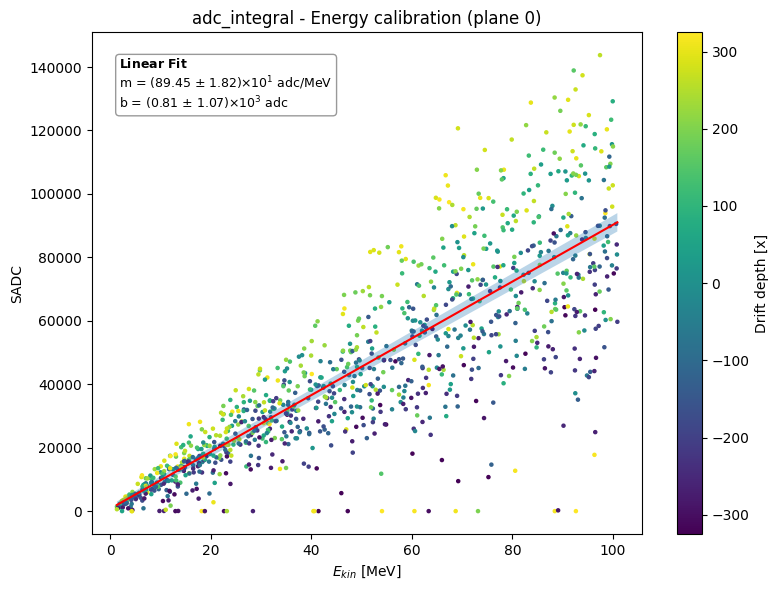

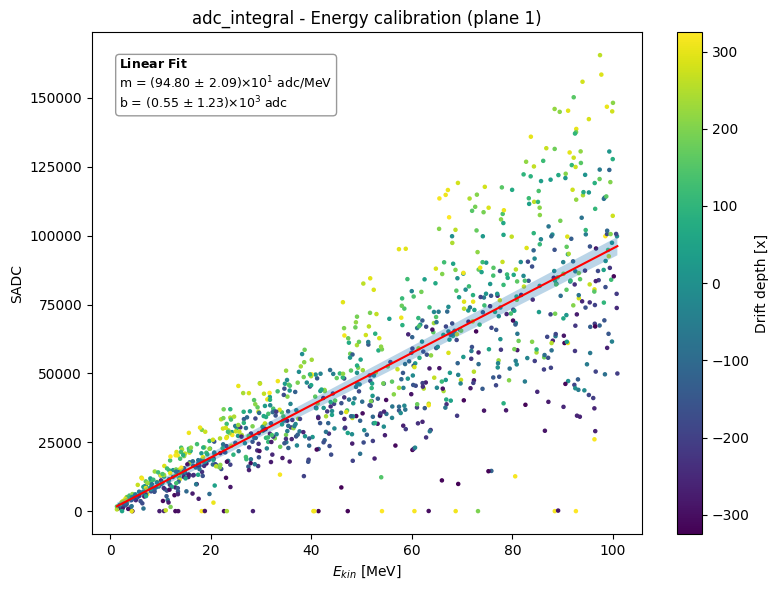

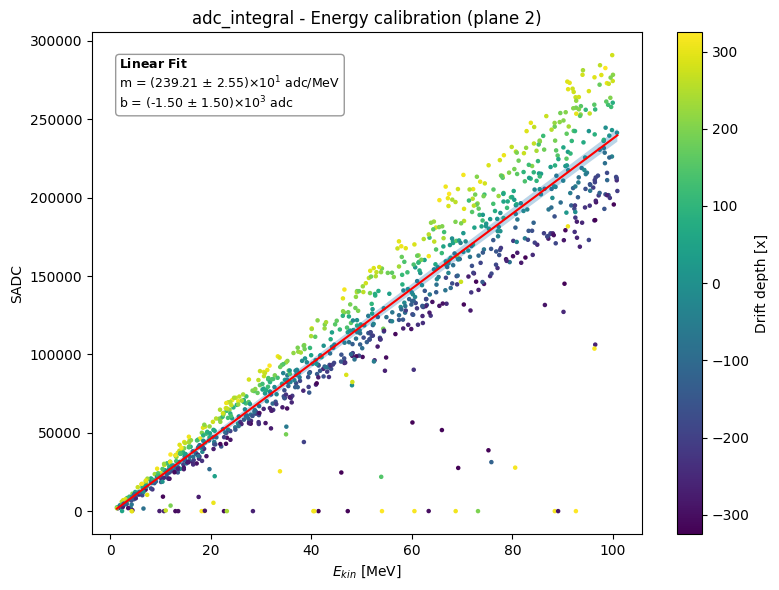

In [13]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    fig = gm_ca.plot_calibration(rop)

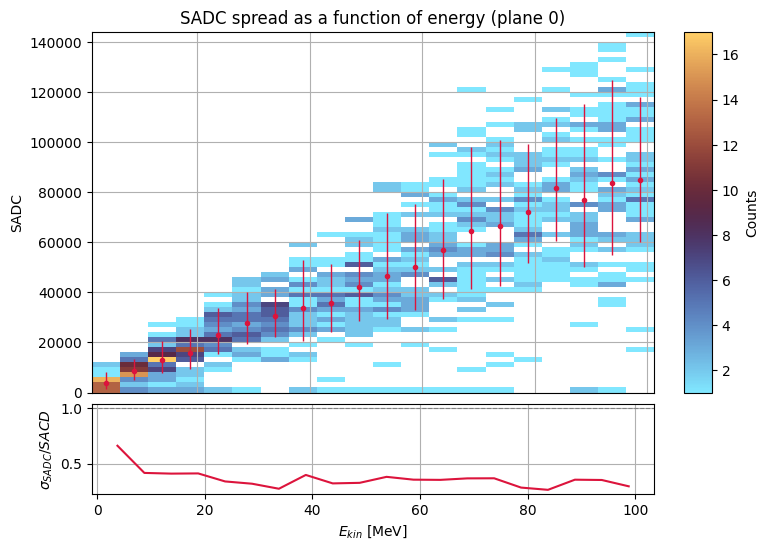

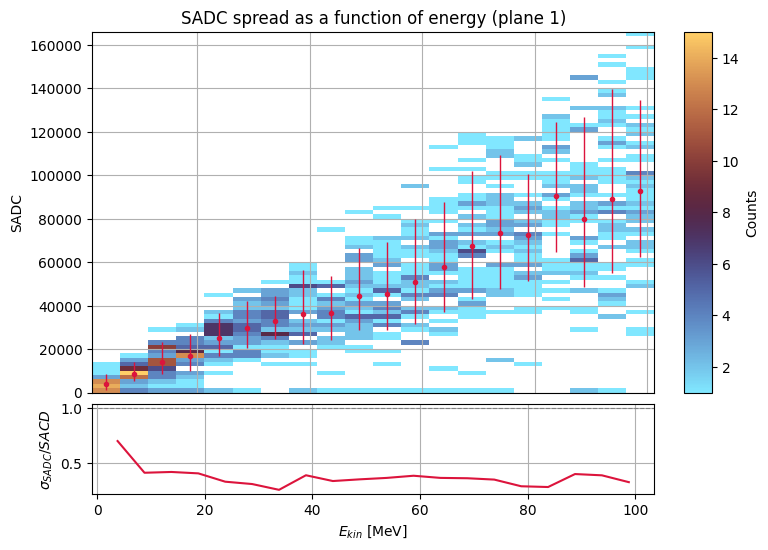

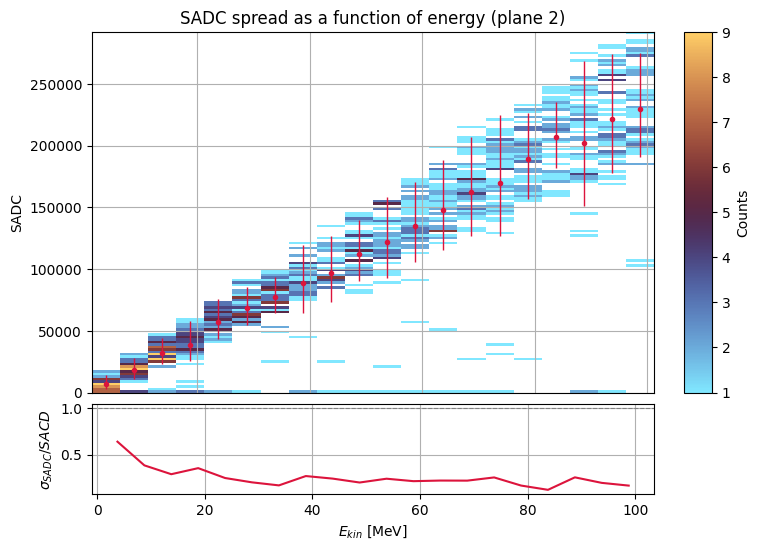

In [14]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    gm_ca.plot_calibration_spread(rop, cmap='managua_r')